In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

In [3]:
prices_0 = pd.read_csv("data/ROUND_3/prices_round_3_day_0.csv", delimiter=";")
prices_1 = pd.read_csv("data/ROUND_3/prices_round_3_day_1.csv", delimiter=';')
prices_2 = pd.read_csv("data/ROUND_3/prices_round_3_day_2.csv", delimiter=";")

In [4]:
prices_0.head(10)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0
3,0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,6,104.0,13.0,NaN,NaN,101.5,0.0
4,0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,25,NaN,NaN,NaN,NaN,53.0,0.0
5,0,0,VELVETFRUIT_EXTRACT,5247,67,NaN,NaN,NaN,NaN,5253,67,NaN,NaN,NaN,NaN,5250.0,0.0
6,0,0,VEV_4500,742,6,740.0,13.0,NaN,NaN,758,6,760.0,13.0,NaN,NaN,750.0,0.0
7,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0
8,0,0,VEV_5000,254,19,NaN,NaN,NaN,NaN,260,6,261.0,13.0,NaN,NaN,257.0,0.0
9,0,0,VEV_4000,1240,7,1237.0,24.0,NaN,NaN,1260,7,1263.0,24.0,NaN,NaN,1250.0,0.0


In [5]:
ve = []
for df in [prices_0, prices_1, prices_2]:
    ve.append(df.query("product == 'VELVETFRUIT_EXTRACT'"))

In [6]:
ve[0]

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
5,0,0,VELVETFRUIT_EXTRACT,5247,67,NaN,NaN,NaN,NaN,5253,67,NaN,NaN,NaN,NaN,5250.0,0.0
13,0,100,VELVETFRUIT_EXTRACT,5248,69,NaN,NaN,NaN,NaN,5253,23,5254.0,46.0,NaN,NaN,5250.5,0.0
25,0,200,VELVETFRUIT_EXTRACT,5248,20,5247.0,40.0,NaN,NaN,5253,60,NaN,NaN,NaN,NaN,5250.5,0.0
47,0,300,VELVETFRUIT_EXTRACT,5248,24,5247.0,40.0,NaN,NaN,5253,64,NaN,NaN,NaN,NaN,5250.5,0.0
55,0,400,VELVETFRUIT_EXTRACT,5248,25,5247.0,37.0,NaN,NaN,5253,62,NaN,NaN,NaN,NaN,5250.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119951,0,999500,VELVETFRUIT_EXTRACT,5242,63,NaN,NaN,NaN,NaN,5247,19,5248.0,44.0,NaN,NaN,5244.5,0.0
119962,0,999600,VELVETFRUIT_EXTRACT,5243,56,NaN,NaN,NaN,NaN,5245,11,5248.0,25.0,5249.0,31.0,5244.0,0.0
119965,0,999700,VELVETFRUIT_EXTRACT,5243,20,5242.0,37.0,NaN,NaN,5248,57,NaN,NaN,NaN,NaN,5245.5,0.0
119980,0,999800,VELVETFRUIT_EXTRACT,5243,24,5242.0,44.0,NaN,NaN,5248,68,NaN,NaN,NaN,NaN,5245.5,0.0


In [7]:
velvet = ve[0]
ts = 1000000
for df in ve[1:]:
    df["timestamp"] += ts
    ts += 1000000
    velvet = pd.concat([velvet, df], ignore_index=True)

In [8]:
velvet

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,VELVETFRUIT_EXTRACT,5247,67,NaN,NaN,NaN,NaN,5253,67,NaN,NaN,NaN,NaN,5250.0,0.0
1,0,100,VELVETFRUIT_EXTRACT,5248,69,NaN,NaN,NaN,NaN,5253,23,5254.0,46.0,NaN,NaN,5250.5,0.0
2,0,200,VELVETFRUIT_EXTRACT,5248,20,5247.0,40.0,NaN,NaN,5253,60,NaN,NaN,NaN,NaN,5250.5,0.0
3,0,300,VELVETFRUIT_EXTRACT,5248,24,5247.0,40.0,NaN,NaN,5253,64,NaN,NaN,NaN,NaN,5250.5,0.0
4,0,400,VELVETFRUIT_EXTRACT,5248,25,5247.0,37.0,NaN,NaN,5253,62,NaN,NaN,NaN,NaN,5250.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,2,2999500,VELVETFRUIT_EXTRACT,5293,55,NaN,NaN,NaN,NaN,5298,24,5299.0,31.0,NaN,NaN,5295.5,0.0
29996,2,2999600,VELVETFRUIT_EXTRACT,5294,53,NaN,NaN,NaN,NaN,5299,23,5300.0,30.0,NaN,NaN,5296.5,0.0
29997,2,2999700,VELVETFRUIT_EXTRACT,5295,23,5294.0,48.0,NaN,NaN,5300,71,NaN,NaN,NaN,NaN,5297.5,0.0
29998,2,2999800,VELVETFRUIT_EXTRACT,5294,24,5293.0,43.0,NaN,NaN,5299,24,5300.0,43.0,NaN,NaN,5296.5,0.0


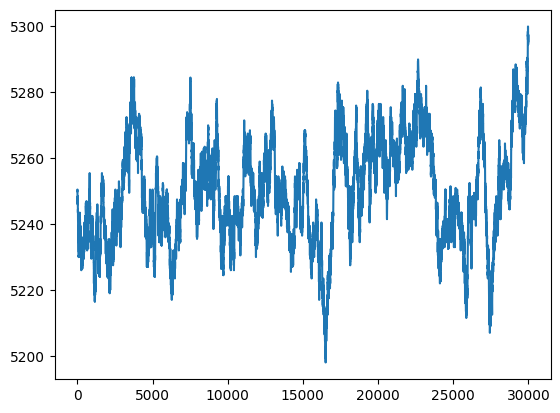

In [9]:
plt.plot(velvet["mid_price"])

(array([4.000e+00, 8.000e+00, 2.100e+01, 7.900e+01, 1.900e+02, 3.360e+02,
        1.329e+03, 1.418e+03, 4.619e+03, 3.224e+03, 7.400e+03, 3.238e+03,
        4.820e+03, 1.407e+03, 1.254e+03, 3.750e+02, 1.850e+02, 6.500e+01,
        2.300e+01, 4.000e+00]),
 array([-1.04587602e-03, -9.45771923e-04, -8.45667830e-04, -7.45563737e-04,
        -6.45459643e-04, -5.45355550e-04, -4.45251457e-04, -3.45147364e-04,
        -2.45043271e-04, -1.44939177e-04, -4.48350840e-05,  5.52690092e-05,
         1.55373102e-04,  2.55477196e-04,  3.55581289e-04,  4.55685382e-04,
         5.55789475e-04,  6.55893569e-04,  7.55997662e-04,  8.56101755e-04,
         9.56205848e-04]),
 <BarContainer object of 20 artists>)

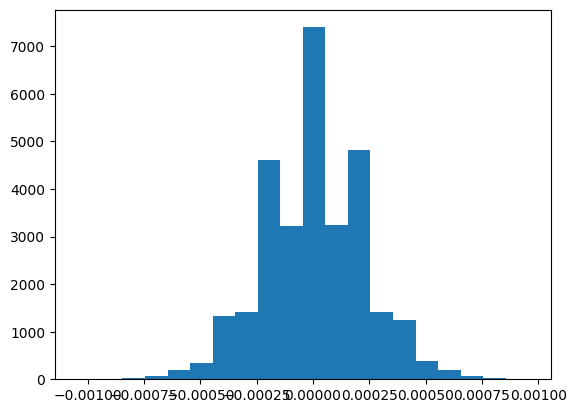

In [10]:
plt.hist(np.log(velvet["mid_price"]).diff(), bins=20)

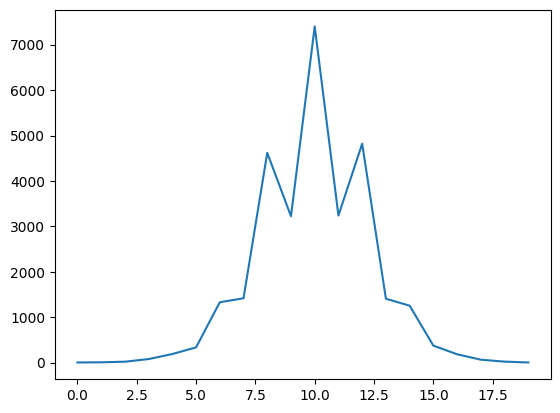

In [11]:
plt.plot([4.000e+00, 8.000e+00, 2.100e+01, 7.900e+01, 1.900e+02, 3.360e+02, 1.329e+03, 1.418e+03, 4.619e+03, 3.224e+03, 7.400e+03, 3.238e+03, 4.820e+03, 1.407e+03, 1.254e+03, 3.750e+02, 1.850e+02, 6.500e+01,2.300e+01, 4.000e+00])

In [12]:
from plotter import Plotter

In [13]:
viz = Plotter("data/ROUND_3")
viz.visualize_orderbook()

interactive(children=(Dropdown(description='Product:', options=('HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4…

In [14]:
counts = np.array([4., 8., 21., 79., 190., 336., 1329., 1418., 4619., 3224., 7400., 3238., 4820., 1407., 1254., 375., 185., 65., 23., 4.])
edges = np.array([-1.04587602e-03, -9.45771923e-04, -8.45667830e-04, -7.45563737e-04, -6.45459643e-04, -5.45355550e-04, -4.45251457e-04, -3.45147364e-04, -2.45043271e-04, -1.44939177e-04, -4.48350840e-05,  5.52690092e-05, 1.55373102e-04,  2.55477196e-04,  3.55581289e-04,  4.55685382e-04, 5.55789475e-04,  6.55893569e-04,  7.55997662e-04,  8.56101755e-04, 9.56205848e-04])

# Calculate the center of each bin for easier reading
bin_centers = (edges[:-1] + edges[1:]) / 2

# Print them out side-by-side
print(f"{'Bin Center':>12} | {'Count':>7}")
print("-" * 22)
for center, count in zip(bin_centers, counts):
    print(f"{center:12.6f} | {count:7.0f}")

  Bin Center |   Count
----------------------
   -0.000996 |       4
   -0.000896 |       8
   -0.000796 |      21
   -0.000696 |      79
   -0.000595 |     190
   -0.000495 |     336
   -0.000395 |    1329
   -0.000295 |    1418
   -0.000195 |    4619
   -0.000095 |    3224
    0.000005 |    7400
    0.000105 |    3238
    0.000205 |    4820
    0.000306 |    1407
    0.000406 |    1254
    0.000506 |     375
    0.000606 |     185
    0.000706 |      65
    0.000806 |      23
    0.000906 |       4


(array([1.000e+00, 0.000e+00, 3.000e+00, 0.000e+00, 8.000e+00, 0.000e+00,
        1.000e+00, 2.000e+01, 0.000e+00, 7.900e+01, 0.000e+00, 1.900e+02,
        0.000e+00, 0.000e+00, 3.360e+02, 0.000e+00, 1.329e+03, 0.000e+00,
        1.025e+03, 3.930e+02, 0.000e+00, 4.619e+03, 0.000e+00, 3.224e+03,
        0.000e+00, 0.000e+00, 7.400e+03, 0.000e+00, 3.238e+03, 0.000e+00,
        4.820e+03, 0.000e+00, 0.000e+00, 1.407e+03, 0.000e+00, 1.254e+03,
        0.000e+00, 1.480e+02, 2.270e+02, 0.000e+00, 1.850e+02, 0.000e+00,
        6.500e+01, 0.000e+00, 0.000e+00, 2.200e+01, 0.000e+00, 4.000e+00,
        0.000e+00, 1.000e+00]),
 array([-1.04587602e-03, -1.00583438e-03, -9.65792742e-04, -9.25751105e-04,
        -8.85709467e-04, -8.45667830e-04, -8.05626193e-04, -7.65584555e-04,
        -7.25542918e-04, -6.85501281e-04, -6.45459643e-04, -6.05418006e-04,
        -5.65376369e-04, -5.25334732e-04, -4.85293094e-04, -4.45251457e-04,
        -4.05209820e-04, -3.65168182e-04, -3.25126545e-04, -2.85084908e-

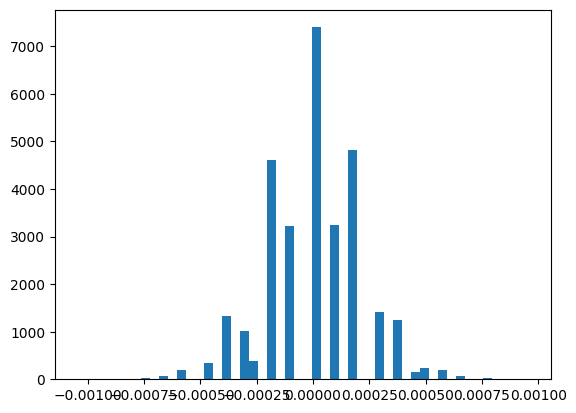

In [15]:
plt.hist(np.log(velvet["mid_price"]).diff(), bins=50)

In [28]:
np.log(5240/5241)

np.float64(-0.00019082148707838263)

In [29]:
prices_0.head(10)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0
3,0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,6,104.0,13.0,NaN,NaN,101.5,0.0
4,0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,25,NaN,NaN,NaN,NaN,53.0,0.0
5,0,0,VELVETFRUIT_EXTRACT,5247,67,NaN,NaN,NaN,NaN,5253,67,NaN,NaN,NaN,NaN,5250.0,0.0
6,0,0,VEV_4500,742,6,740.0,13.0,NaN,NaN,758,6,760.0,13.0,NaN,NaN,750.0,0.0
7,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0
8,0,0,VEV_5000,254,19,NaN,NaN,NaN,NaN,260,6,261.0,13.0,NaN,NaN,257.0,0.0
9,0,0,VEV_4000,1240,7,1237.0,24.0,NaN,NaN,1260,7,1263.0,24.0,NaN,NaN,1250.0,0.0


In [30]:
all_prices = pd.concat([prices_0, prices_1, prices_2], ignore_index=True)
all_prices

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,25,NaN,NaN,NaN,NaN,23.0,0.0
1,0,0,VEV_6500,0,16,NaN,NaN,NaN,NaN,1,16,NaN,NaN,NaN,NaN,0.5,0.0
2,0,0,VEV_5500,8,25,NaN,NaN,NaN,NaN,9,25,NaN,NaN,NaN,NaN,8.5,0.0
3,0,0,VEV_5200,100,19,NaN,NaN,NaN,NaN,103,6,104.0,13.0,NaN,NaN,101.5,0.0
4,0,0,VEV_5300,52,6,51.0,19.0,NaN,NaN,54,25,NaN,NaN,NaN,NaN,53.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359995,2,999900,VELVETFRUIT_EXTRACT,5293,25,5292.0,39.0,NaN,NaN,5298,64,NaN,NaN,NaN,NaN,5295.5,0.0
359996,2,999900,VEV_4500,787,10,785.0,17.0,NaN,NaN,804,10,806.0,17.0,NaN,NaN,795.5,0.0
359997,2,999900,VEV_5400,19,28,NaN,NaN,NaN,NaN,21,28,NaN,NaN,NaN,NaN,20.0,0.0
359998,2,999900,VEV_6500,0,11,NaN,NaN,NaN,NaN,1,11,NaN,NaN,NaN,NaN,0.5,0.0


In [33]:
all_prices["product"].unique()

<StringArray>
[           'VEV_5400',            'VEV_6500',            'VEV_5500',
            'VEV_5200',            'VEV_5300', 'VELVETFRUIT_EXTRACT',
            'VEV_4500',       'HYDROGEL_PACK',            'VEV_5000',
            'VEV_4000',            'VEV_5100',            'VEV_6000']
Length: 12, dtype: str

In [35]:
options = ['VEV_5400',            'VEV_6500',            'VEV_5500',
            'VEV_5200',            'VEV_5300',
            'VEV_4500',                  'VEV_5000',
            'VEV_4000',            'VEV_5100',            'VEV_6000']

In [90]:
option_dict = {}
for option in options:
    df = all_prices.query(f"product == '{option}'")
    
    underlying_fairs = all_prices.query("product == 'VELVETFRUIT_EXTRACT'").rename(columns={"mid_price" : "velvetfruit_price"})[["day", "timestamp", "velvetfruit_price"]]
    df = df.merge(underlying_fairs, how="left", on=["day", "timestamp"])
    
    df["r"] = 0.0
    
    # --- NEW CONTINUOUS TIME PROCESSING ---
    # 1. Calculate the exact fraction of the day that has passed (0.0 to ~0.9999)
    fractional_day = df["timestamp"].astype(float) / 1000000.0
    
    # 2. Subtract the full days passed AND the intraday fraction
    # Example Day 0, TS 500,000 -> 7 - 0 - 0.5 = 6.5 days left
    continuous_days = 8.0 - df["day"].astype(float) - fractional_day
    
    # 3. Annualize for Black-Scholes
    # Using 252 (standard trading days in a year) is typical for exchange simulation data
    df["T_years"] = continuous_days / 252.0 
    df["strike"] = df["product"].str.split('_').str[-1].astype(float)
    option_dict[option] = df
    

In [91]:
option_dict["VEV_5400"]["T_years"]

0        0.031746
1        0.031746
2        0.031745
3        0.031745
4        0.031744
           ...   
29995    0.019843
29996    0.019843
29997    0.019842
29998    0.019842
29999    0.019842
Name: T_years, Length: 30000, dtype: float64

In [92]:
from scipy.stats import norm
from scipy.optimize import brentq

def bs_call_price(S, K, T, r, sigma):
    """Calculates the theoretical Black-Scholes price for a European Call."""
    if T <= 0:
        return np.maximum(S - K, 0.0)
        
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def calculate_iv(row, K_col='strike', S_col='velvetfruit_price', T_col='T_years', r_col='r', price_col='mid_price'):
    """Objective function to find the root (Implied Volatility)."""
    S = row[S_col]
    K = row[K_col]
    T = row[T_col]
    r = row[r_col]
    market_price = row[price_col]
    
    # Check for intrinsic value violations (arbitrage). IV is undefined here.
    intrinsic_value = np.maximum(S - K, 0.0)
    if market_price <= intrinsic_value or T <= 0:
        return np.nan
        
    def objective_function(sigma):
        return bs_call_price(S, K, T, r, sigma) - market_price

    try:
        # Search for a volatility between 0.1% and 500%
        return brentq(objective_function, 1e-3, 5.0)
    except ValueError:
        return np.nan

# ---------------------------------------------------------
# 2. Main Processing Loop
# ---------------------------------------------------------

def process_orderbook_iv(options_dict):
    """
    Iterates through the dictionary of dataframes, calculates IV, and plots it.
    Returns a completely new dictionary of DataFrames, preserving the original.
    """
    new_options_dict = {}
    plt.figure(figsize=(12, 6))
    
    for strike_str, df in options_dict.items():
        print(f"Processing Strike: {strike_str}")
        
        # 1. Create a completely independent copy of the dataframe
        calc_df = df.copy()
        
        # 3. Calculate IV row by row (now utilizing the native 'strike' column)
        calc_df['implied_volatility'] = calc_df.apply(
            calculate_iv, 
            axis=1,
            K_col='strike',
            S_col='velvetfruit_price', 
            T_col='T_years',
            r_col='r',
            price_col='mid_price'
        )
        
        # 4. Store the modified DataFrame in the NEW dictionary
        new_options_dict[strike_str] = calc_df
        
        # 5. Plotting (removed the type casting for timestamp)
        plt.plot(calc_df['timestamp'], calc_df['implied_volatility'], label=f'Strike {strike_str}')

    # Finalize Plot
    plt.title('Call Option Implied Volatility Over Time by Strike')
    plt.xlabel('Timestamp')
    plt.ylabel(r'Implied Volatility ($\sigma$)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return new_options_dict

Processing Strike: VEV_5400
Processing Strike: VEV_6500
Processing Strike: VEV_5500
Processing Strike: VEV_5200
Processing Strike: VEV_5300
Processing Strike: VEV_4500
Processing Strike: VEV_5000
Processing Strike: VEV_4000
Processing Strike: VEV_5100
Processing Strike: VEV_6000


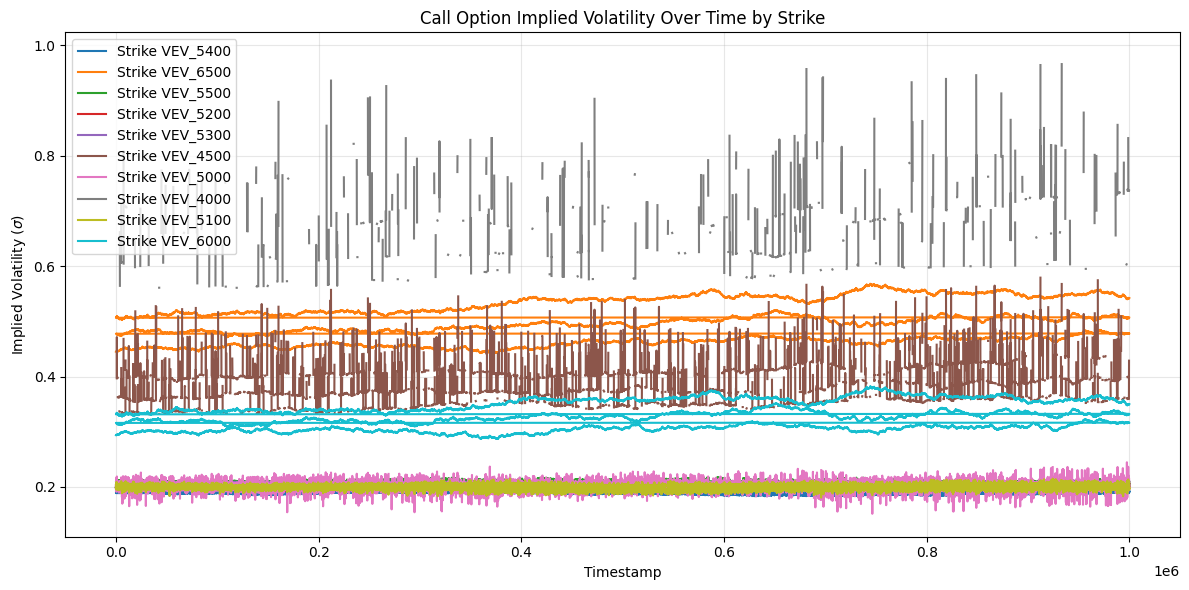

In [93]:
iv_dict = process_orderbook_iv(option_dict)

In [94]:
iv_dict["VEV_5400"]

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,velvetfruit_price,r,T_years,strike,implied_volatility
0,0,0,VEV_5400,22,25,NaN,NaN,NaN,NaN,24,...,NaN,NaN,NaN,23.0,0.0,5250.0,0.0,0.031746,5400.0,0.199320
1,0,100,VEV_5400,23,17,NaN,NaN,NaN,NaN,24,...,NaN,NaN,NaN,23.5,0.0,5250.5,0.0,0.031746,5400.0,0.200728
2,0,200,VEV_5400,23,10,22.0,14.0,NaN,NaN,24,...,NaN,NaN,NaN,23.5,0.0,5250.5,0.0,0.031745,5400.0,0.200729
3,0,300,VEV_5400,23,9,22.0,11.0,NaN,NaN,24,...,NaN,NaN,NaN,23.5,0.0,5250.5,0.0,0.031745,5400.0,0.200730
4,0,400,VEV_5400,23,6,22.0,13.0,NaN,NaN,24,...,NaN,NaN,NaN,23.5,0.0,5250.5,0.0,0.031744,5400.0,0.200731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,2,999500,VEV_5400,20,25,NaN,NaN,NaN,NaN,21,...,NaN,NaN,NaN,20.5,0.0,5295.5,0.0,0.019843,5400.0,0.194640
29996,2,999600,VEV_5400,20,19,NaN,NaN,NaN,NaN,21,...,NaN,NaN,NaN,20.5,0.0,5296.5,0.0,0.019843,5400.0,0.193602
29997,2,999700,VEV_5400,20,23,NaN,NaN,NaN,NaN,21,...,NaN,NaN,NaN,20.5,0.0,5297.5,0.0,0.019842,5400.0,0.192562
29998,2,999800,VEV_5400,20,27,NaN,NaN,NaN,NaN,21,...,NaN,NaN,NaN,20.5,0.0,5296.5,0.0,0.019842,5400.0,0.193606


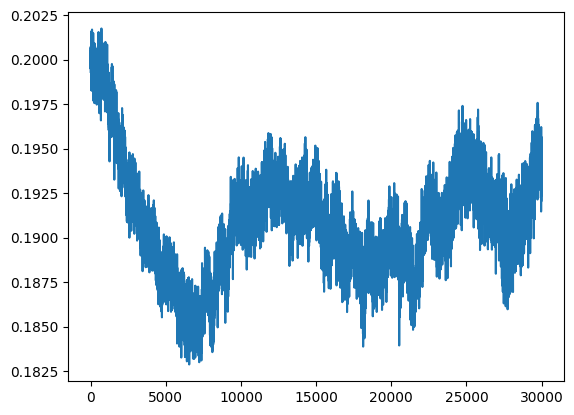

In [95]:
plt.plot(iv_dict["VEV_5400"]["implied_volatility"])

In [96]:
iv_dict.keys()

dict_keys(['VEV_5400', 'VEV_6500', 'VEV_5500', 'VEV_5200', 'VEV_5300', 'VEV_4500', 'VEV_5000', 'VEV_4000', 'VEV_5100', 'VEV_6000'])

In [97]:
import plotly.graph_objects as go
import pandas as pd
from typing import Dict

def plot_implied_volatility(iv_dict: Dict[str, pd.DataFrame]):
    """
    Plots Implied Volatility over time continuously across multiple days using a global timestamp.
    """
    fig = go.Figure()

    # Sort the dictionary keys numerically so the legend is cleanly ordered
    sorted_strikes = sorted(iv_dict.keys())

    for strike_label in sorted_strikes:
        df = iv_dict[strike_label].copy()
        
        # Drop rows where IV couldn't be calculated
        df = df.dropna(subset=['implied_volatility'])
        
        # Create the global timestamp: Day * 1,000,000 + Timestamp
        df['global_timestamp'] = (df['day'].astype(float) * 1000000.0) + df['timestamp'].astype(float)
        
        fig.add_trace(go.Scatter(
            x=df['global_timestamp'],
            y=df['implied_volatility'],
            mode='lines',
            name=f'Strike {strike_label}',
            # Format the hover text to 4 decimal places for readability
            hovertemplate=f"IV {strike_label}: %{{y:.4f}}<extra></extra>"
        ))

    # Configure the layout
    fig.update_layout(
        title='Call Option Implied Volatility Over Time by Strike',
        xaxis_title='Global Timestamp',
        yaxis_title='Implied Volatility ($\sigma$)',
        # 'x unified' draws a vertical line and shows ALL strikes at the exact timestamp you hover over
        hovermode='x unified', 
        template='plotly_white', 
        legend_title='Strikes',
        margin=dict(l=60, r=40, t=60, b=40),
        # Ensure the x-axis displays as plain integers, not scientific notation
        xaxis=dict(tickformat="d") 
    )

    fig.show()

# Example usage:
plot_implied_volatility(iv_dict)

<>:36: SyntaxWarning: invalid escape sequence '\s'
<>:36: SyntaxWarning: invalid escape sequence '\s'
/var/folders/gk/j2jhsn3n1h5bcjdtj9ldkt_40000gn/T/ipykernel_28097/1178206788.py:36: SyntaxWarning: invalid escape sequence '\s'
  yaxis_title='Implied Volatility ($\sigma$)',


In [98]:
import plotly.graph_objects as go
import plotly.colors as pc
import pandas as pd
import numpy as np
from typing import Dict

def plot_sampled_volatility_smiles(
    iv_dict: Dict[str, pd.DataFrame], 
    start_ts: float = 0, 
    end_ts: float = 2999000, 
    step_size: float = 200000
):
    """
    Samples data uniformly over time and plots overlapping Volatility Smiles.
    Guarantees no mutation or copying of the original DataFrames.
    """
    # 1. Generate the uniform sample points
    sampled_timestamps = np.arange(start_ts, end_ts + 1, step_size)
    
    # 2. Get a color scale to represent time passing (dark to light)
    colors = pc.sample_colorscale("Plasma", len(sampled_timestamps))
    
    fig = go.Figure()
    
    for i, target_ts in enumerate(sampled_timestamps):
        # Reverse-engineer the target day and target intraday timestamp
        # e.g., 1,500,000 -> target_day = 1, target_intraday = 500,000
        target_day = int(target_ts // 1000000)
        target_intraday = int(target_ts % 1000000)
        
        smile_data = []
        
        # Gather data across all strikes for this specific microsecond
        for strike_label, df in iv_dict.items():
            # Filter directly on your original columns (Read-Only)
            snapshot = df[
                (df['day'].astype(float) == target_day) & 
                (df['timestamp'].astype(float) == target_intraday)
            ]
            
            if not snapshot.empty:
                iv = snapshot['implied_volatility'].values[0]
                S = snapshot['velvetfruit_price'].values[0]
                K = snapshot['strike'].values[0]
                
                # Check for NaNs
                if pd.notna(iv):
                    smile_data.append({
                        'strike': K,
                        'moneyness': K - S,
                        'implied_volatility': iv
                    })
        
        if not smile_data:
            continue
            
        # Convert to DataFrame and sort from left to right
        smile_df = pd.DataFrame(smile_data).sort_values(by='moneyness')
        
        # 3. Add the line to the plot
        fig.add_trace(go.Scatter(
            x=smile_df['moneyness'],
            y=smile_df['implied_volatility'],
            mode='lines+markers',
            line=dict(width=2, color=colors[i], shape='spline'),
            marker=dict(size=6),
            name=f'TS: {int(target_ts):,}',
            customdata=smile_df['strike'],
            hovertemplate=(
                f"<b>Timestamp:</b> {int(target_ts):,}<br>" +
                "<b>Strike:</b> %{customdata}<br>" +
                "<b>Moneyness:</b> %{x:.2f}<br>" +
                "<b>IV:</b> %{y:.4f}<extra></extra>"
            )
        ))

    # Add vertical dashed line at exactly 0.0 (At-The-Money)
    fig.add_vline(x=0, line_dash="dash", line_color="gray", annotation_text="ATM (S = K)")

    # Configure Layout
    fig.update_layout(
        title=f'Evolution of the Volatility Smile (Sampled every {int(step_size):,} ticks)',
        xaxis_title='Moneyness (Strike - Underlying Price)',
        yaxis_title=r'Implied Volatility ($\sigma$)',
        template='plotly_white',
        hovermode='closest',
        legend_title='Global Timestamp',
        margin=dict(l=60, r=40, t=60, b=40)
    )

    fig.show()

plot_sampled_volatility_smiles(iv_dict, start_ts=2000000, end_ts=2999000, step_size=20000)